In [ ]:
import pandas as pd

df = pd.read_csv('/content/soil_data.csv')
display(df.head())

,nitrogen,phosphorus,potassium,ph,moisture,temperature
0,102,112,2,7.593434,39.233405,17.453748
1,179,82,84,6.854970,16.682529,5.429927
2,92,41,281,7.901562,32.192959,19.350064
3,14,100,116,8.469421,32.538814,5.630633
4,106,5,220,7.870044,57.924892,29.588287


In [ ]:
print("Missing values before handling:")
display(df.isnull().sum())

df_cleaned = df.dropna()

print("\nMissing values after handling:")
display(df_cleaned.isnull().sum())

print("\nShape of the DataFrame after handling missing values:")
print(df_cleaned.shape)

print("\nFirst 5 rows of the cleaned DataFrame:")
display(df_cleaned.head())

Missing values before handling:


,0
nitrogen,0
phosphorus,0
potassium,0
ph,0
moisture,0
temperature,0



Missing values after handling:


,0
nitrogen,0
phosphorus,0
potassium,0
ph,0
moisture,0
temperature,0



Shape of the DataFrame after handling missing values:
(1000, 6)

First 5 rows of the cleaned DataFrame:


,nitrogen,phosphorus,potassium,ph,moisture,temperature
0,102,112,2,7.593434,39.233405,17.453748
1,179,82,84,6.854970,16.682529,5.429927
2,92,41,281,7.901562,32.192959,19.350064
3,14,100,116,8.469421,32.538814,5.630633
4,106,5,220,7.870044,57.924892,29.588287


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

features_scaled = scaler.fit_transform(features)

print("Scaled features (first 5 rows):")
display(pd.DataFrame(features_scaled, columns=features.columns).head())

Scaled features (first 5 rows):


,nitrogen,phosphorus,potassium,ph,moisture,temperature
0,0.022621,0.901345,-1.734918,0.800388,0.304140,-0.278342
1,1.359417,0.212577,-0.764308,0.059769,-1.252415,-1.679629
2,-0.150988,-0.728740,1.567523,1.109415,-0.181821,-0.057341
3,-1.505145,0.625838,-0.385533,1.678931,-0.157948,-1.656238
4,0.092065,-1.555262,0.845484,1.077805,1.594304,1.135848


In [ ]:
features = df_cleaned[['nitrogen', 'phosphorus', 'potassium', 'ph', 'moisture', 'temperature']]
print("Selected features for clustering:")
display(features.head())

Selected features for clustering:


,nitrogen,phosphorus,potassium,ph,moisture,temperature
0,102,112,2,7.593434,39.233405,17.453748
1,179,82,84,6.854970,16.682529,5.429927
2,92,41,281,7.901562,32.192959,19.350064
3,14,100,116,8.469421,32.538814,5.630633
4,106,5,220,7.870044,57.924892,29.588287


In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(features_scaled)
    wcss.append(kmeans.inertia_)


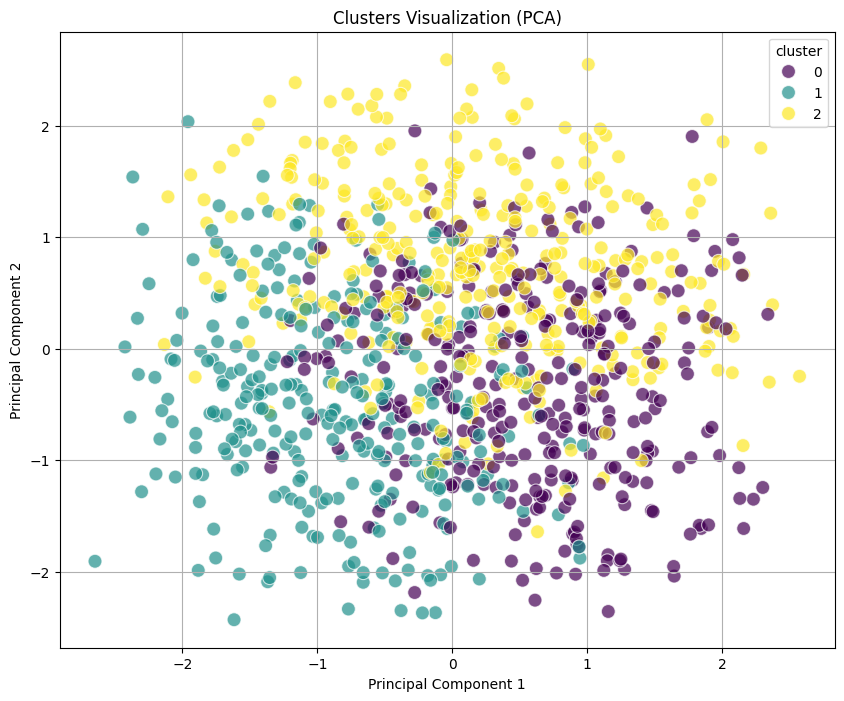

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

pca = PCA(n_components=2)
pca_components = pca.fit_transform(features_scaled)

df_cleaned['pca1'] = pca_components[:, 0]
df_cleaned['pca2'] = pca_components[:, 1]

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='pca1',
    y='pca2',
    hue='cluster',
    data=df_cleaned,
    palette='viridis',
    s=100,
    alpha=0.7
)
plt.title('Clusters Visualization (PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()


In [ ]:
print("Cluster Centers (Mean of each feature per cluster):")
cluster_centers = df_cleaned.groupby('cluster')[['nitrogen', 'phosphorus', 'potassium', 'ph', 'moisture', 'temperature']].mean()
display(cluster_centers)

Cluster Centers (Mean of each feature per cluster):


,nitrogen,phosphorus,potassium,ph,moisture,temperature
cluster,,,,,,
0,145.422619,40.443452,137.761905,6.781268,37.419022,18.870381
1,39.009934,52.420530,161.480132,6.798870,32.096148,19.974735
2,110.646409,119.671271,147.834254,6.805554,34.699701,20.633316


In [ ]:
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
clusters = kmeans.fit_predict(features_scaled)

df_cleaned['cluster'] = clusters

print("DataFrame with cluster labels (first 5 rows):")
display(df_cleaned.head())

DataFrame with cluster labels (first 5 rows):


,nitrogen,phosphorus,potassium,ph,moisture,temperature,cluster
0,102,112,2,7.593434,39.233405,17.453748,2
1,179,82,84,6.854970,16.682529,5.429927,0
2,92,41,281,7.901562,32.192959,19.350064,1
3,14,100,116,8.469421,32.538814,5.630633,1
4,106,5,220,7.870044,57.924892,29.588287,0
